# Packages Utilisé

In [64]:
! pip install pandas -q
! pip install matplotlib -q
! pip install cartiflette -q
import pandas as pd
import matplotlib.pyplot as plt



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Données du projet

In [65]:
df = pd.read_csv(
'https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb'  
)
df.head()

C:\Users\user\AppData\Local\Temp\ipykernel_29252\4263583973.py:1: DtypeWarning: Columns (0: prenom) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix
0,01,Ain,1,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3
1,01,Ain,2,L'Abergement-de-Varey,Nathalie,ARTHAUD,2
2,01,Ain,4,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38
3,01,Ain,5,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8
4,01,Ain,6,Ambléon,Nathalie,ARTHAUD,0


## Question 1

In [66]:
# code_commune : on concatène le code département (2 chiffres) et le code commune (3 chiffres)
df['code_commune'] = (
    df['code_departement'].astype(str).str.zfill(2)
    + df['code_commune'].astype(str).str.zfill(3)
)

# candidat : prénom + nom
df['candidat'] = df['prenom'].astype(str) + ' ' + df['nom'].astype(str)

# Vérification : Montrouge doit être 92049
assert '92049' in df['code_commune'].values, "Montrouge (92049) introuvable !"
print("code_commune correct – exemple Montrouge :", df[df['code_commune'] == '92049']['libelle_commune'].iloc[0])

df[['code_commune', 'libelle_commune', 'candidat', 'voix']].head()

code_commune correct – exemple Montrouge : Montrouge


,code_commune,libelle_commune,candidat,voix
0,01001,L'Abergement-Clémenciat,Nathalie ARTHAUD,3
1,01002,L'Abergement-de-Varey,Nathalie ARTHAUD,2
2,01004,Ambérieu-en-Bugey,Nathalie ARTHAUD,38
3,01005,Ambérieux-en-Dombes,Nathalie ARTHAUD,8
4,01006,Ambléon,Nathalie ARTHAUD,0


## Question 2


In [67]:
# Exclusion des lignes non-candidats (abstentions, blancs, nuls)
# On identifie les votes non exprimés : ils ont généralement un nom spécifique
non_candidats = ['ABSTENTION', 'BLANC', 'NUL', 'EXPRIME']
masque_candidats = ~df['nom'].str.upper().isin(non_candidats)

candidats = df[masque_candidats]['candidat'].nunique()

print(f"En 2022, il y avait {candidats} candidats à l'élection présidentielle.")

En 2022, il y avait 12 candidats à l'élection présidentielle.


## Question 3: Comparaison des scores départements aux moyennes nationales

In [68]:
# Votes exprimés uniquement (on exclut les non-candidats)
df_candidats = df[masque_candidats].copy()

# Scores nationaux
total_exprime = df_candidats['voix'].sum()

score_national = (
    df_candidats
    .groupby('candidat', as_index=False)['voix']
    .sum()
    .rename(columns={'voix': 'votes_national'})
    .sort_values('votes_national', ascending=False)
    .reset_index(drop=True)
)

score_national['score_national'] = score_national['votes_national'] / total_exprime * 100

# Affichage propre
display_df = score_national.copy()
display_df['votes_national'] = display_df['votes_national'].apply(lambda x: f"{x:,.0f}".replace(',', ' '))
display_df['score_national'] = display_df['score_national'].apply(lambda x: f"{x:.2f}%")
display_df.index += 1  # classement à partir de 1

print("\n Résultats du 1er tour – 10 avril 2022\n")
display_df


 Résultats du 1er tour – 10 avril 2022



,candidat,votes_national,score_national
1,Emmanuel MACRON,9 783 058,20.07%
2,Marine LE PEN,8 133 828,16.69%
3,Jean-Luc MÉLENCHON,7 712 520,15.82%
4,Éric ZEMMOUR,2 485 226,5.10%
5,Valérie PÉCRESSE,1 679 001,3.44%
6,Yannick JADOT,1 627 853,3.34%
7,Jean LASSALLE,1 101 387,2.26%
8,Fabien ROUSSEL,802 422,1.65%
9,Nicolas DUPONT-AIGNAN,725 176,1.49%
10,Anne HIDALGO,616 478,1.26%


###  Question 4 – Scores par département

In [69]:
# Votes par département et par candidat
votes_dep = (
    df_candidats
    .groupby(['code_departement', 'candidat'], as_index=False)['voix']
    .sum()
    .rename(columns={'voix': 'votes_departement'})
)

# Total des votes exprimés par département
total_dep = (
    df_candidats
    .groupby('code_departement')['voix']
    .sum()
    .reset_index()
    .rename(columns={'voix': 'total_dep'})
)

score_departements = votes_dep.merge(total_dep, on='code_departement')
score_departements['score_departement'] = score_departements['votes_departement'] / score_departements['total_dep'] * 100
score_departements = score_departements.drop(columns='total_dep')
score_departements = score_departements.sort_values(['code_departement', 'votes_departement'], ascending=[True, False])

# Vérification pour l'Aude (11)
print(" Vérification pour le département 11 (Aude) :")
aude = score_departements[score_departements['code_departement'] == '11'].copy()
aude['score_departement'] = aude['score_departement'].apply(lambda x: f"{x:.2f}%")
aude

 Vérification pour le département 11 (Aude) :


,code_departement,candidat,votes_departement,score_departement
125,11,Marine LE PEN,64027,22.87%
121,11,Emmanuel MACRON,43104,15.40%
124,11,Jean-Luc MÉLENCHON,42039,15.02%
131,11,Éric ZEMMOUR,18434,6.59%
123,11,Jean LASSALLE,12382,4.42%
129,11,Valérie PÉCRESSE,7350,2.63%
130,11,Yannick JADOT,6322,2.26%
120,11,Anne HIDALGO,6166,2.20%
122,11,Fabien ROUSSEL,5622,2.01%
127,11,Nicolas DUPONT-AIGNAN,4206,1.50%


###  Question 5 – Jointure avec le niveau national

In [80]:
score_departements = score_departements.merge(
    score_national[['candidat', 'votes_national', 'score_national']],
    on='candidat'
)

# Vérification pour l'Aude
print(" Vérification pour le département 11 (Aude) – 3 premiers candidats :")
check = score_departements[score_departements['code_departement'] == '11'].head(3).copy()
check['score_departement'] = check['score_departement'].apply(lambda x: f"{x:.2f}%")
check['score_national'] = check['score_national'].apply(lambda x: f"{x:.2f}%")
check

 Vérification pour le département 11 (Aude) – 3 premiers candidats :


,code_departement,candidat,votes_departement,score_departement,votes_national_x,score_national_x,surrepresentation,votes_national_y,score_national_y,votes_national,score_national
120,11,Marine LE PEN,64027,22.87%,8133828,16.685502,37.081572,8133828,16.685502,8133828,16.69%
121,11,Emmanuel MACRON,43104,15.40%,9783058,20.068686,-23.272004,9783058,20.068686,9783058,20.07%
122,11,Jean-Luc MÉLENCHON,42039,15.02%,7712520,15.821243,-5.077978,7712520,15.821243,7712520,15.82%


###  Question 6 – Variable `surrepresentation`

In [ ]:
# surrepresentation = (score_dep - score_national) / score_national * 100
score_departements['surrepresentation'] = (
    (score_departements['score_departement'] - score_departements['score_national'])
    / score_departements['score_national']
    * 100
)


print("Exemple (dept 11, Marine Le Pen) :",
      round(score_departements[
          (score_departements['code_departement'] == '11') &
          (score_departements['candidat'] == 'Marine LE PEN')
      ]['surrepresentation'].values[0], 2), "%")

score_departements.head()

Exemple (dept 11, Marine Le Pen) : 37.08 %


,code_departement,candidat,votes_departement,score_departement,votes_national,score_national,surrepresentation
0,01,Emmanuel MACRON,92206,21.046361,9783058,20.068686,4.871644
1,01,Marine LE PEN,86755,19.802150,8133828,16.685502,18.678774
2,01,Jean-Luc MÉLENCHON,57832,13.200368,7712520,15.821243,-16.565545
3,01,Éric ZEMMOUR,27530,6.283824,2485226,5.098122,23.257639
4,01,Valérie PÉCRESSE,17572,4.010874,1679001,3.444255,16.451145


###  Question 7 – Visualisation des surreprésentations

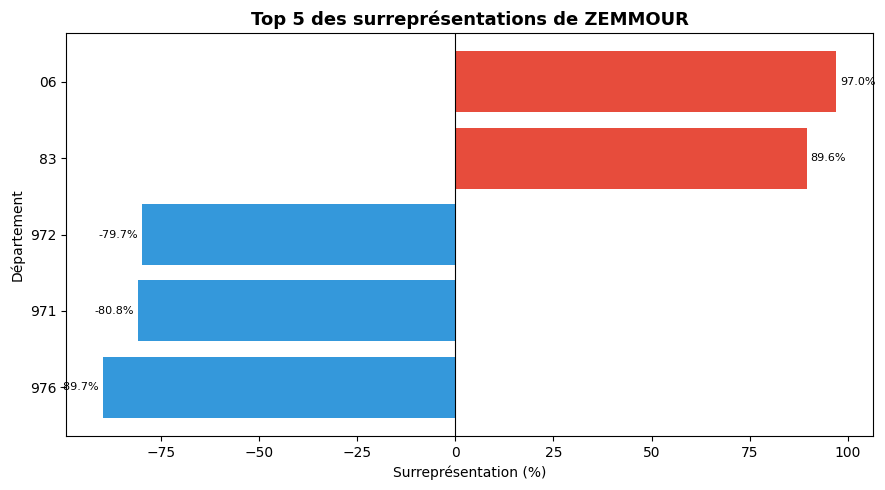

In [ ]:
def plot_surrepresentation(candidat_nom, score_departements, top_n=10):
    
    data = score_departements[score_departements['candidat'] == candidat_nom].copy()
    
    if data.empty:
        print(f"Candidat '{candidat_nom}' introuvable.")
        return
    
    # Top N en valeur absolue
    top = (
        data.reindex(data['surrepresentation'].abs().sort_values(ascending=False).index)
        .head(top_n)
        .sort_values('surrepresentation')
    )
    
    nom_court = candidat_nom.split()[-1]  
    
    fig, ax = plt.subplots(figsize=(9, 5))
    colors = ['#e74c3c' if v >= 0 else '#3498db' for v in top['surrepresentation']]
    
    ax.barh(top['code_departement'].astype(str), top['surrepresentation'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Surreprésentation (%)')
    ax.set_ylabel('Département')
    ax.set_title(f'Top {top_n} des surreprésentations de {nom_court}', fontsize=13, fontweight='bold')
    
    # Annotations valeurs
    for i, (val, dep) in enumerate(zip(top['surrepresentation'], top['code_departement'])):
        ha = 'left' if val >= 0 else 'right'
        offset = 1 if val >= 0 else -1
        ax.text(val + offset, i, f"{val:.1f}%", va='center', ha=ha, fontsize=8)
    
    plt.tight_layout()
    plt.show()


# Test sur Éric Zemmour
plot_surrepresentation('Éric ZEMMOUR', score_departements, top_n=5)

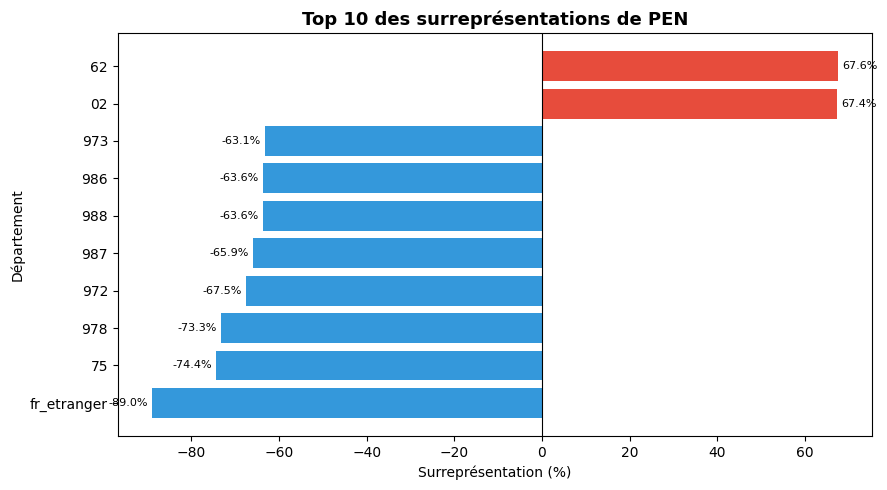

In [73]:
# Test sur Marine Le Pen
plot_surrepresentation('Marine LE PEN', score_departements, top_n=10)

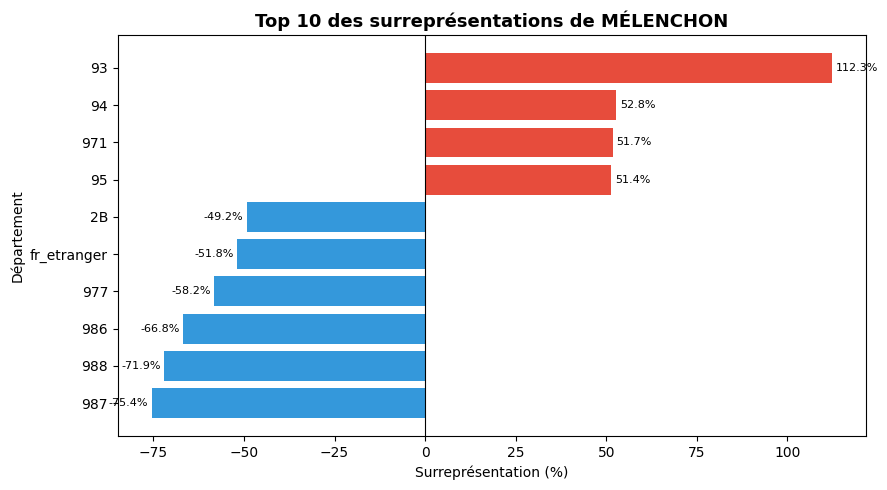

In [74]:
# Test sur Jean-Luc Mélenchon
plot_surrepresentation('Jean-Luc MÉLENCHON', score_departements, top_n=10)

## 3. Cartographie


### Question 8 – Carte choroplèthe par candidat

In [ ]:
from cartiflette import carti_download

departement_borders = carti_download(
    values=["France"],
    crs=4326,
    borders="DEPARTEMENT",
    vectorfile_format="geojson",
    simplification=50,
    filter_by="FRANCE_ENTIERE_DROM_RAPPROCHES",
    source="EXPRESS-COG-CARTO-TERRITOIRE",
    year=2022
)

print(departement_borders.columns.tolist())
departement_borders.head(2)

['INSEE_DEP', 'PAYS', 'LIBELLE_DEPARTEMENT', 'POPULATION', 'SOURCE', 'geometry']


,INSEE_DEP,PAYS,LIBELLE_DEPARTEMENT,POPULATION,SOURCE,geometry
0,43,France,Haute-Loire,227570,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((3.89745 45.35699, 3.89691 45.35631, ..."
1,65,France,Hautes-Pyrénées,229567,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"MULTIPOLYGON (((-0.09705 43.5822, -0.09642 43...."


In [ ]:
def carte_candidat(candidat_nom, score_departements, departement_borders):
    
    data = score_departements[score_departements['candidat'] == candidat_nom].copy()
    data['code_departement'] = data['code_departement'].astype(str)
    
    # Trouver la colonne de jointure dans le GeoDataFram
    col_dep = [c for c in departement_borders.columns if 'DEP' in c.upper() and 'LIB' not in c.upper()][0]
    
    gdf = departement_borders.merge(
        data[['code_departement', 'surrepresentation']],
        left_on=col_dep,
        right_on='code_departement',
        how='left'
    )
    
    nom_court = candidat_nom.split()[-1]
    vmax = data['surrepresentation'].abs().max()
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    gdf.plot(
        column='surrepresentation',
        cmap='RdBu_r',
        vmin=-vmax, vmax=vmax,
        legend=True,
        legend_kwds={
            'label': '(% par rapport\nmoyenne nationale)',
            'orientation': 'vertical'
        },
        edgecolor='white',
        linewidth=0.3,
        ax=ax
    )
    ax.set_title(f'Surreprésentation – {candidat_nom}', fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()


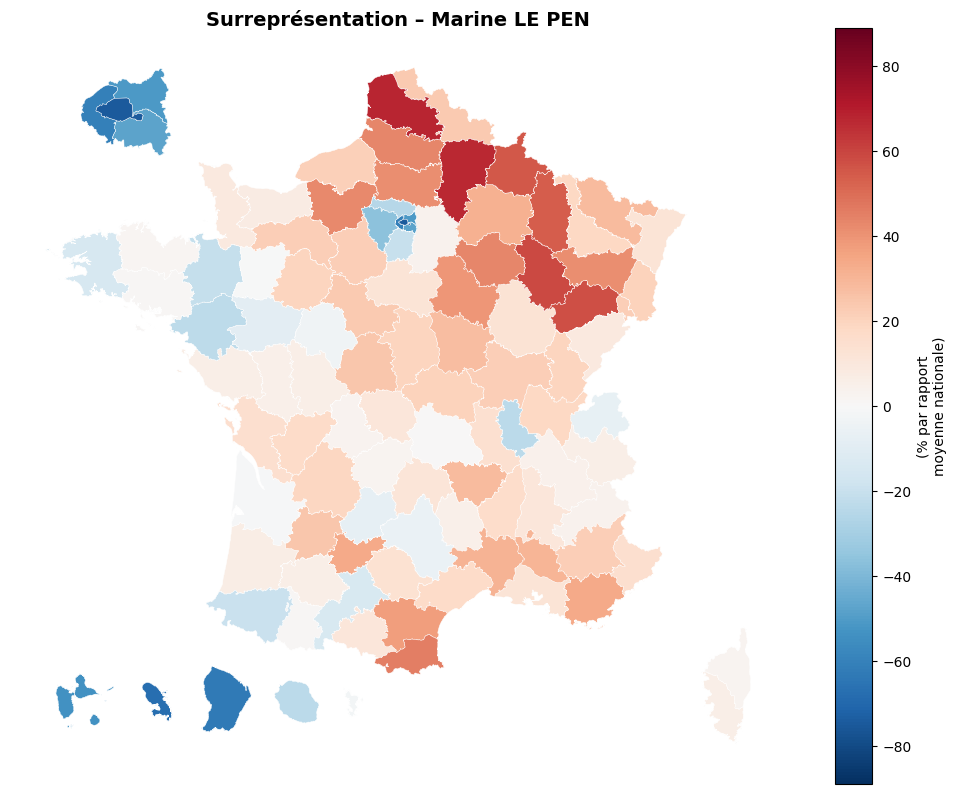

In [82]:
# Test sur Marine Le Pen
carte_candidat('Marine LE PEN', score_departements, departement_borders)

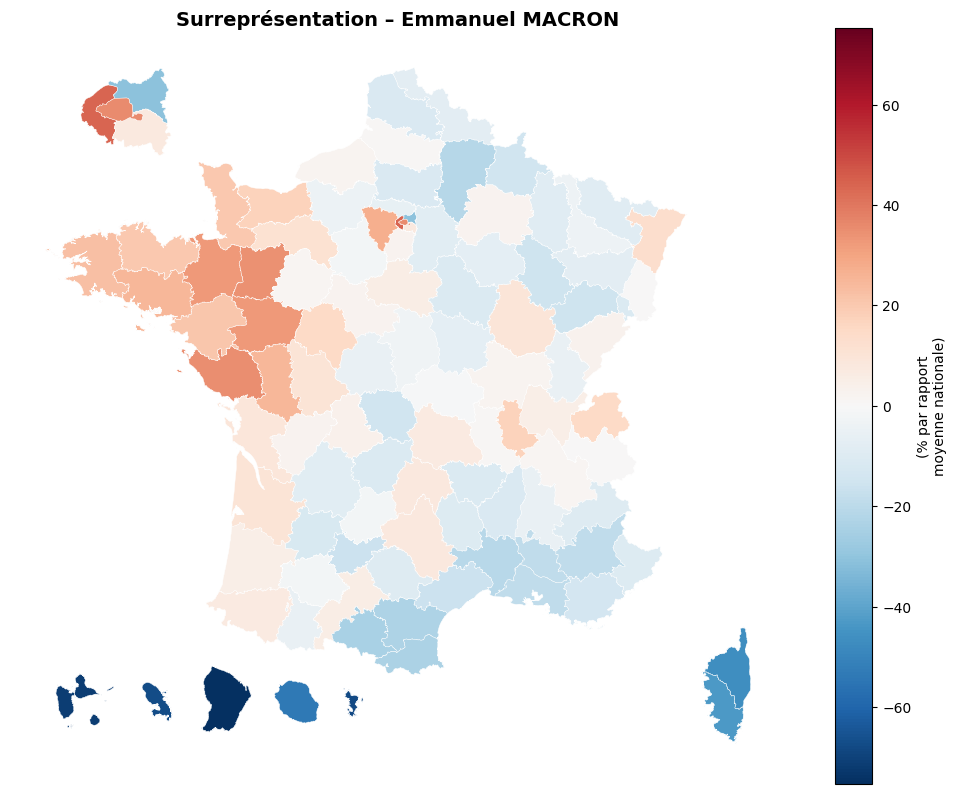

In [77]:
# Carte Emmanuel Macron
carte_candidat('Emmanuel MACRON', score_departements, departement_borders)

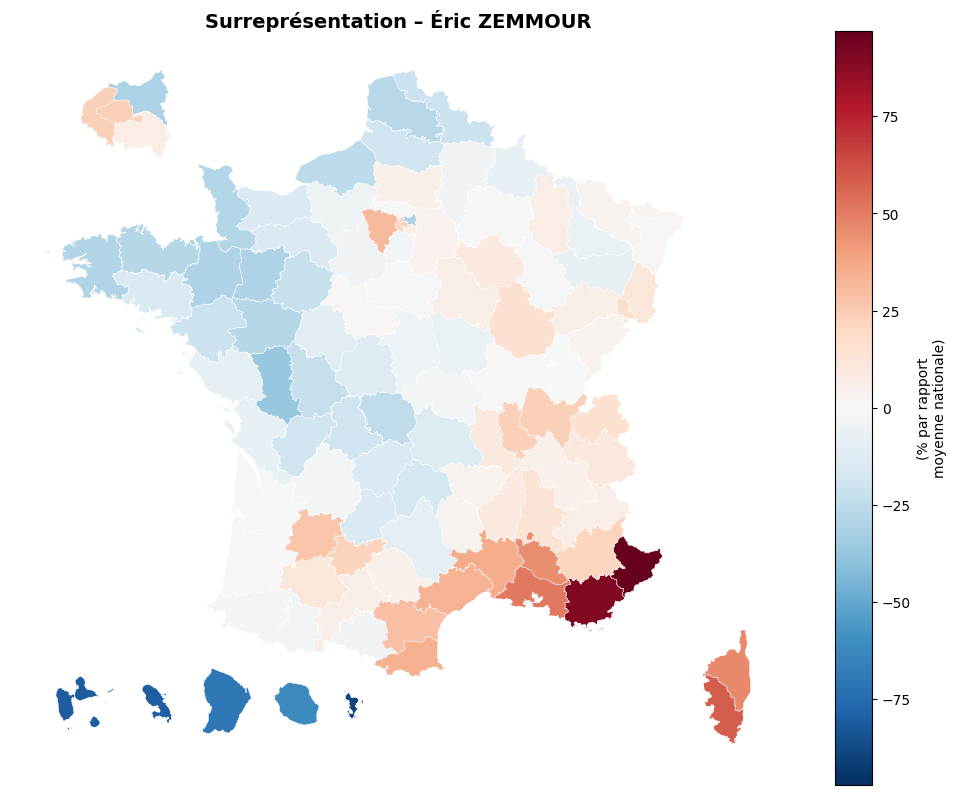

In [78]:
# Carte Éric Zemmour
carte_candidat('Éric ZEMMOUR', score_departements, departement_borders)